# Training Process

In this section, we will go through the steps involved in training our model. We will cover the data preparation, model architecture, training loop, and evaluation metrics to understand how the model learns from the input features and distinguishes between the different classes.

The general idea is to use the classic KAN model to filter data before feeding it into the quantum model. The resulting structure of the classic model acts as a pre-processor, ensuring that the quantum model receives cleaner and more relevant data for training. This is with the purpose of improving the overall performance and efficiency of the quantum model, and use less resources during the quantum training process.

## Data preprocessing

The first step is data preparation, where we organize and preprocess the input features to ensure they are suitable for training the model. This includes normalizing the data, selecting relevant features, and splitting the dataset into training and validation sets.

For this we use `scripts/run_preprocessing.py` which contains the necessary functions to load, normalize, and split the dataset into training and validation sets, for more details refer to the script itself and the `notebooks/EDA_top.ipynb` for an overview of the data exploration and preprocessing steps.

You can go ahead and run the preprocessing script to prepare the data for training using CLI (Command Line Interface), or run it directly within the notebook using the following command:

```bash
cd scripts
python3 run_preprocessing.py
```

This automatically split the data into 5 folds for cross-validation, ensuring that each fold contains a balanced distribution of the different classes and also apply a cut in the invariant mass between 145 GeV and 205 GeV. If you use the flag `--full-dataset`, the script will use the entire dataset without splitting it into folds and without any cut in the invariant mass.

In [ ]:
#!python3 ../scripts/run_preprocessing.py  --force

## Classic KAN

The classic workflow consists of 3 main steps:
1) classic baseline
2) prune nodes and edges to keep the most relevant structure
3) apply a fine-tuning process to the pruned structure.

In this point the process split into 2 separate branches: one for further classic processing and one for quantum model training.

**Classic branch**
This branch continues with further classic processing, leveraging the pruned and fine-tuned structure to fitting the B-spline into analitic formulas for a classic interpretation.

**Quantum branch**
This branch takes the output of the pruned and fine-tuned classic model as input for quantum model training, ensuring that the quantum model receives cleaner and more relevant data. The focus is adjust the B-spline into 2 different bases, chabyshev and sine; here also we implement a random initialization for the quantum model parameters to compare the performance with the standard initialization.

### Baseline training

After tranform and preprocess the data we can run the classic baseline base on [the pykan library](https://github.com/kindxiaoming/pykan), and optmize and modify the model structure as needed into `src/architectures/hep_kan.py`. In `hep_kan.py` we define the architecture focus in improve the logic and RAM usage to plot the function for each edge and the fitting process to avoid spend excessive computational resources and time in front of the computer. For avoid use excessive resources and stack the training process we also implmement a limited number of input data into the hidden layers during the training phase. This approach ensures that the classic model remains efficient and manageable, providing a solid foundation for subsequent quantum model training. 

**Due to limited computational resources, this strategy is crucial for maintaining a balance between model complexity and practical feasibility.**

In [8]:
!cat ../src/architectures/hep_kan.py

# src/architectures/hep_kan.py
import torch
import copy
import inspect
import matplotlib
import matplotlib.pyplot as plt
import sympy
from kan import KAN
import os
import yaml
import numpy as np
import gc
import io

class HEPKAN(KAN):
    def __init__(self, *args, **kwargs):
        """
        Initializes the official KAN model from the library.
        Maintains all original functionality but allows method overrides.
        """
        super().__init__(*args, **kwargs)

    def prune_input(self, threshold=1e-2, active_inputs=None, log_history=True):
        """
        Override of MultKAN.prune_input.

        Method to prune the input layer of the model based on a threshold. 
        If active_inputs is provided, it will use those inputs instead of 
        calculating them based on the threshold.

        Note: This method is a workaround for a bug in the original pykan library.
        Bug: The bug is that when reconstructing the sub-model, MultKAN.prune_input 
        passes `ba

The training loop is in `src/architectures/classic_kan.py`. All the classic steps are condensed into `scripts/train_kan.py`

In [9]:
!cat ../src/architectures/classic_kan.py

# src/architectures/classic_kan.py
import os
import sys
import time
import json
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    f1_score, precision_score,
    recall_score, confusion_matrix
)
import gc
from kan.utils import SYMBOLIC_LIB
from pathlib import Path

sys.path.append(str(Path(__file__).parent.parent.resolve()))
from src.architectures.hep_kan import HEPKAN, prune_fanin
import src.utils.metrics as viz


def clean_memory(*args):
    """Utility function to clean up memory by deleting objects and clearing GPU cache."""
    for obj in args:
        if obj is not None:
            del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


class ClassicKANTrainer:
    def __init__(self, config):
        """Initializes trainer with global CONFIG."""
        self.config = config
        self.device = torch.device("cuda" if torch.cuda

You can delete the "#" symbol in the next cell to run the sample training command. You can change the seed value as you like.

```bash
!python3 ../scripts/train_kan.py --seed 10
```

In [ ]:
# sample
#!python3 ../scripts/train_kan.py --seed 10

In [10]:
!cat ../outputs/top/mass_cut/n5_subset0/seed_10/logs/training_seed_10.log

Starting the automated training pipeline. Seed: 10.

--- Step 1: Loading and Preprocessing Data ---

[CACHE DETECTED] Loading canonical 5-way partition from: '/workspace/QKANs-ML4SCI_2026/data/processed/top/mass_cut/n5/preprocessed_subsets.pt'
>> Selecting subset 0 (seed=10 % n_subsets=5).
Setting global random seed 10 for reproducibility (run seed: subset selection).

--- Step 2: Starting Base Training ---

--- Starting Training for KAN Model ---
Parameters: width=[[22, 0], [9, 9], [1, 0]], grid=5, k=3, lr=0.005
KAN model created with 8568 parameters.
Epoch [1/60] |Training Loss: 0.69073 | Training AUC: 0.63495 | Validation Loss: 0.68499 | Validation AUC: 0.70544
Epoch [1/60] | Checkpoint saved (val_loss: 0.68499 - val_auc: 0.70544).
Epoch [2/60] | Checkpoint saved (val_loss: 0.66928 - val_auc: 0.71633).
Epoch [3/60] | Checkpoint saved (val_loss: 0.64086 - val_auc: 0.73331).
Epoch [4/60] | Checkpoint saved (val_loss: 0.60890 - val_auc: 0.74572).
Epoch [5/60] |Training Loss: 0.59372 | 

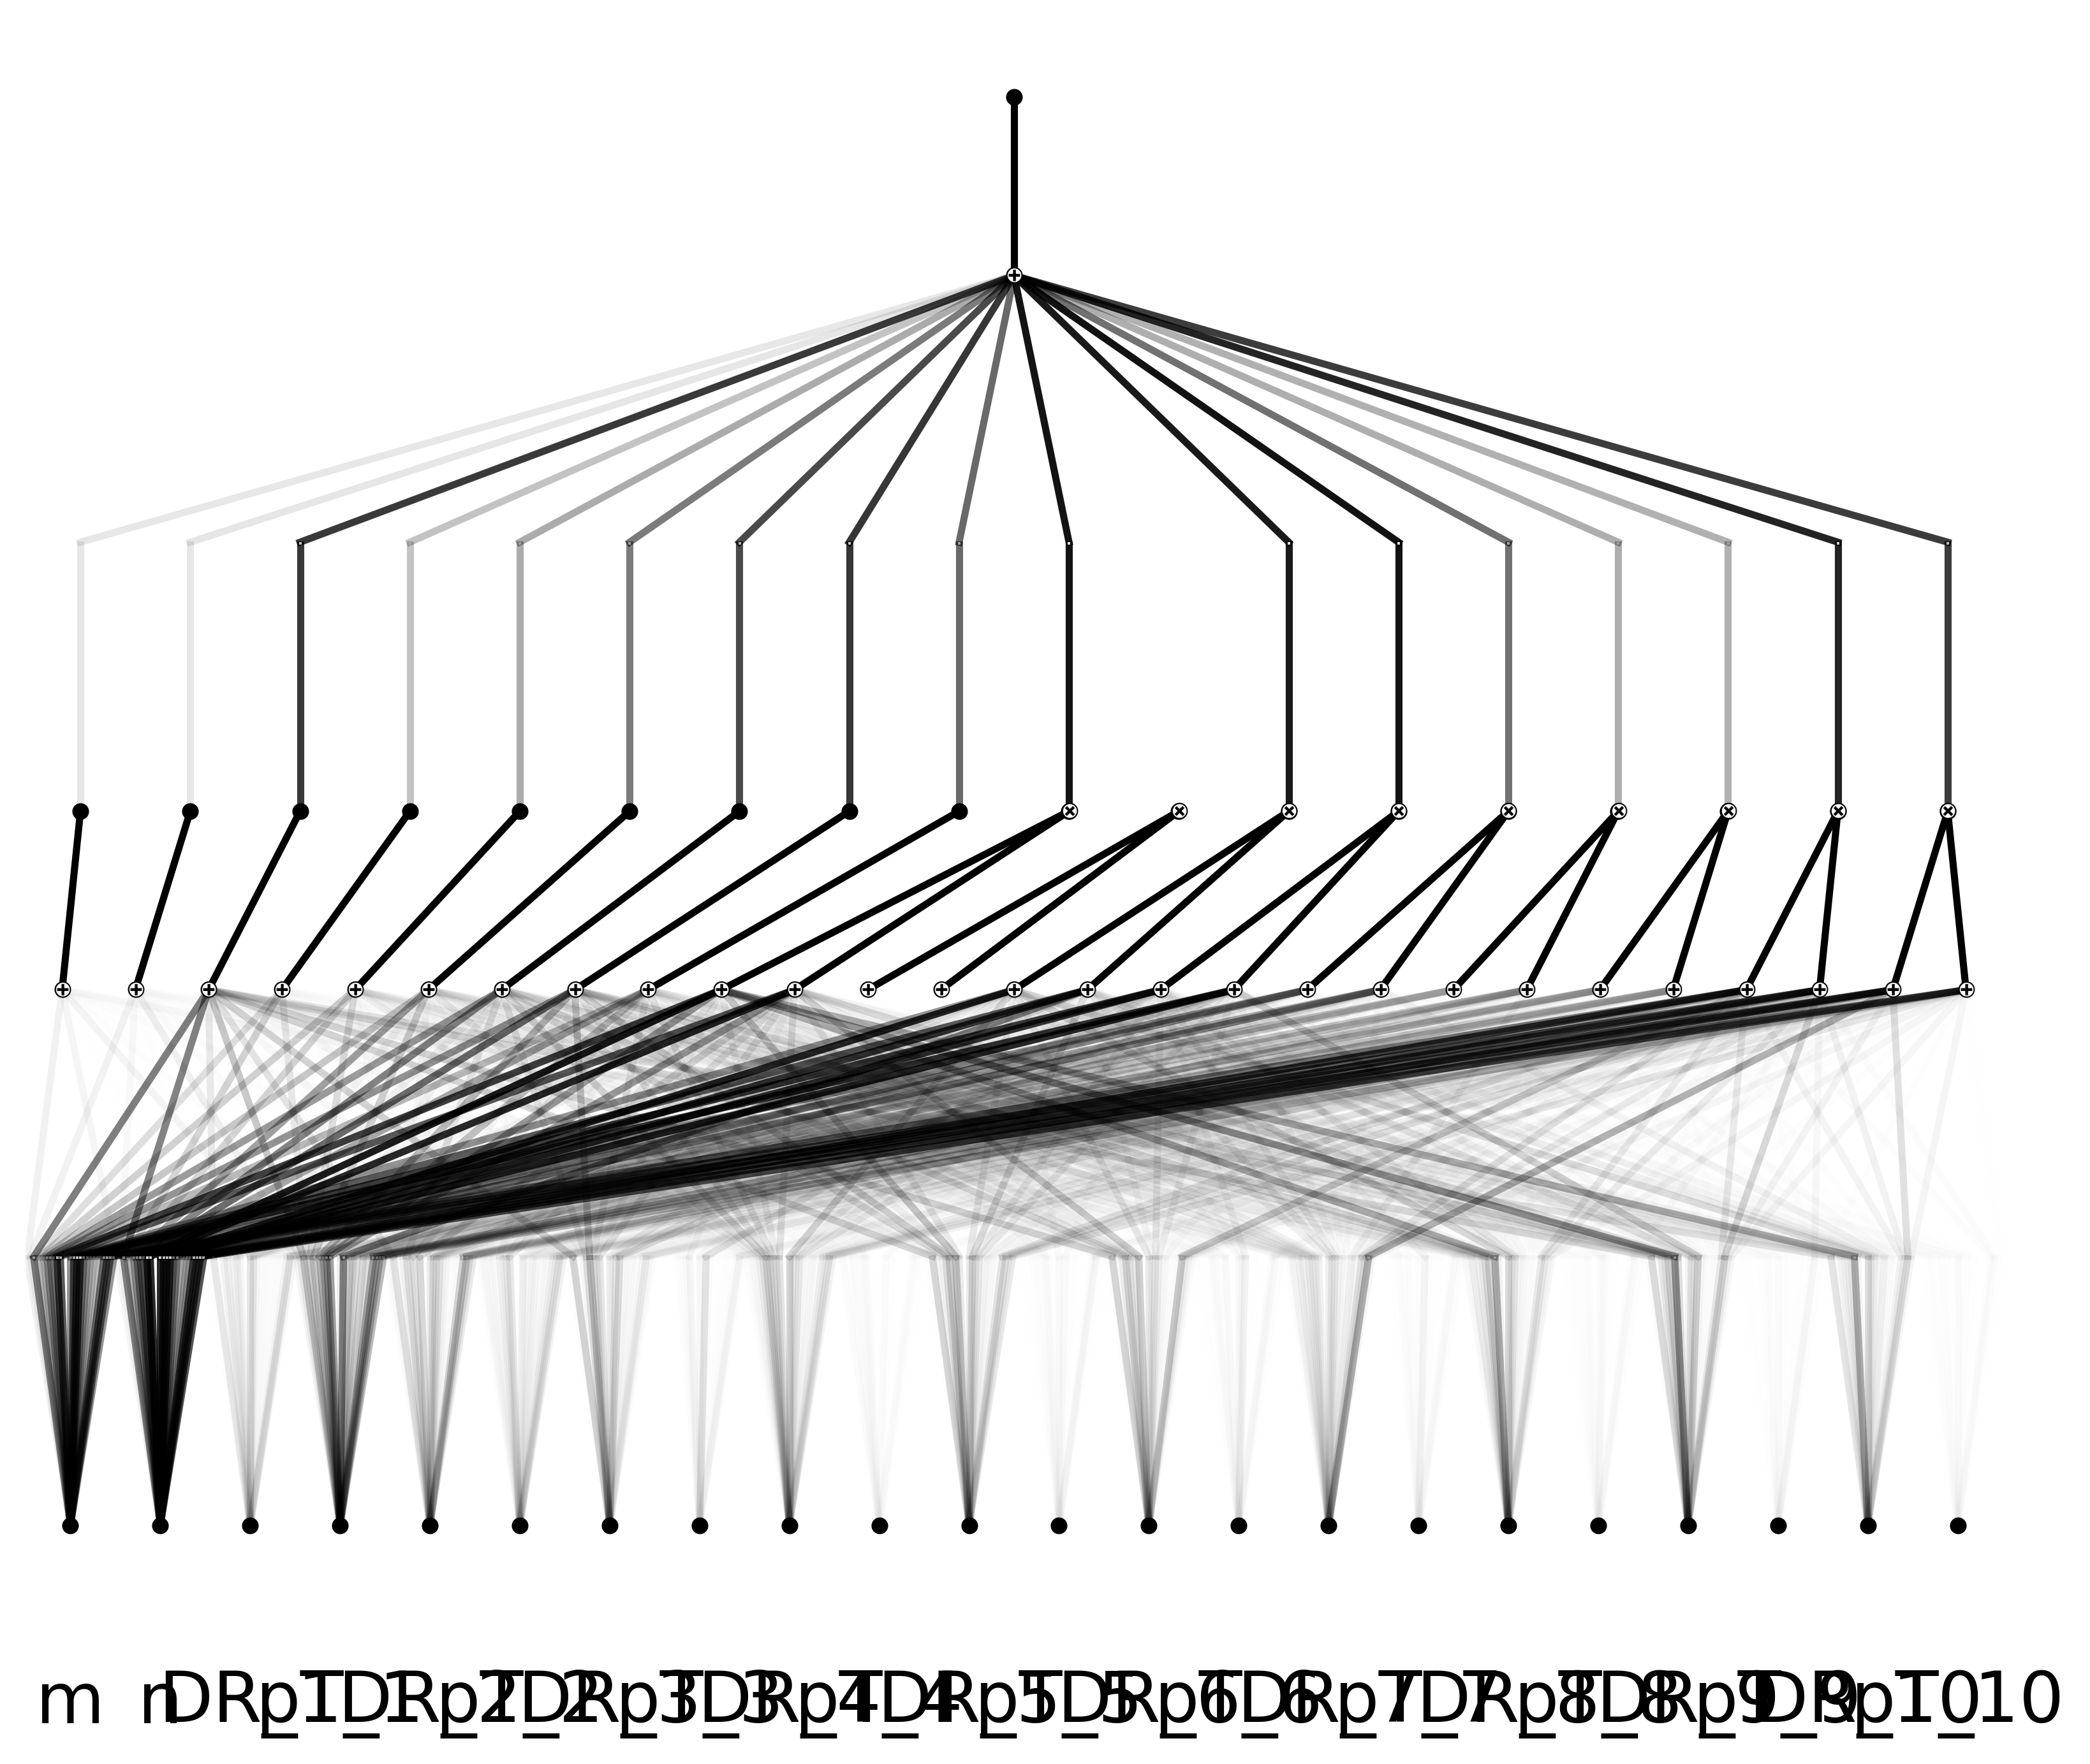

In [ ]:
# show initial model plot
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/01_plot_base/base_model.png")

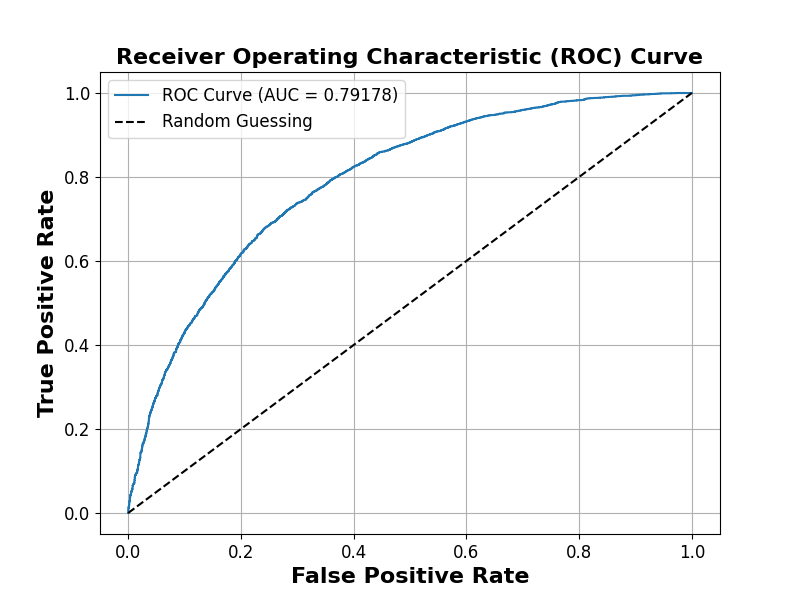

In [ ]:
# show base evaluation ROC curve
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/01_plot_base/base_eval_roc.png")

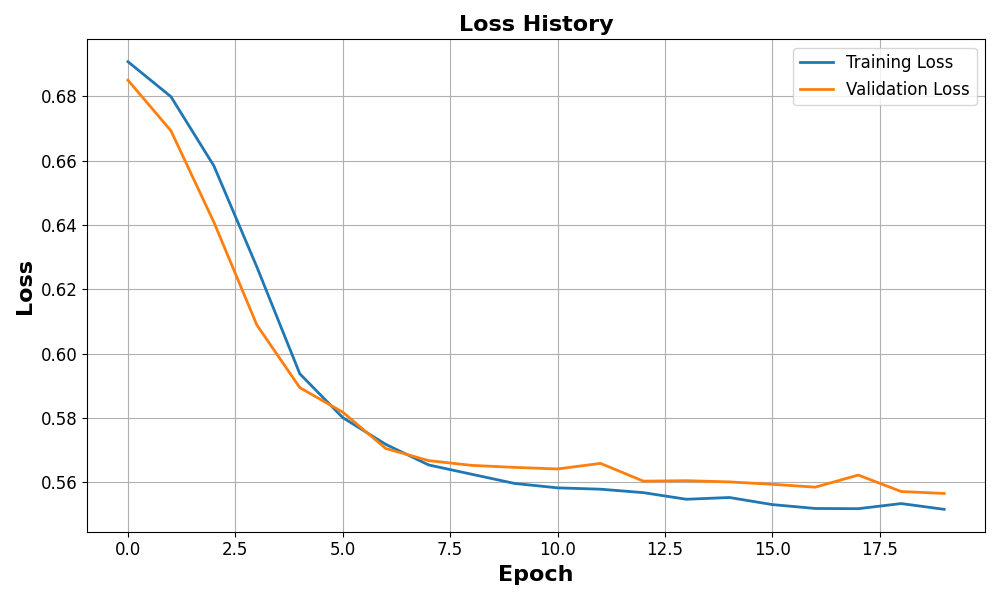

In [ ]:
# show base training loss image
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/01_plot_base/base_train_loss.png")

**Architecture of the classic model and params [22, [9,9,], 1]**

For the training process we select 3 leveles/layers.
1) Input layer: Receives the preprocessed data and passes it to the first hidden layer. The initial number of feature was 22.
2) Hidden layer: Processes the input data, selecting the most relevant features and representations. Here the model take the previous layer's output as input with 9 posible addition nodes and 9 posible moltiplication nodes. [9, 9]
3) Output layer: Produces the final predictions based on the processed information from the hidden layers. It only takes a dimension of 1 as output.

**Importance of multiplication nodes**

The original Kolmogorov-Arnold Theorem says:

> Any multivariate continuous function, $f:[0,1]^n \to \mathbb{R}$, can be represented as a superposition of continuous functions of one variable and addition. 

The multiplication nodes are essential for capturing complex interactions between features, as they allow the model to represent non-linear relationships more effectively and not just rely on additive combinations.

### Prune and fine-tuning

After training the initial classic model, we can proceed to fine-tune it and subsequently use its output as input for the quantum model training. This ensures that the quantum model benefits from a well-optimized and resource-efficient classic model foundation. The idea behind this approach **is that** the model **selects** the most relevant features and representations learned by the classic model, providing a strong starting point for the quantum model to build upon. The hidden layers of the classic model are the one responsible to the number of qubits requiered, that is why was also important to keep only the two more significant inputs from the previous layer. here we select the 2 most relevant features from the previous layer to feed into the hidden layers of the quantum model in each node.

### Symbolic fitting and fine-tuning

One of the main advantages of the KAN architectures is the **interpretability** it offers. By explicitly modeling both additive and multiplicative interactions between features, and also a symbolic fitting option, the model provides clear insights into how different features contribute to the final predictions. This transparency allows researchers to better understand the underlying relationships in the data and facilitates more informed decision-making based on the model's outputs.

For example, we can obtain architectures like this:

In [ ]:
# show an image
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/05_final/final_model.png")


At the bottom are the input features, while the top represents the final output of the model. This layout helps in understanding how each input contributes to the final prediction through the various layers and interactions modeled by the KAN architecture.

## Information transfer

## Quantum model

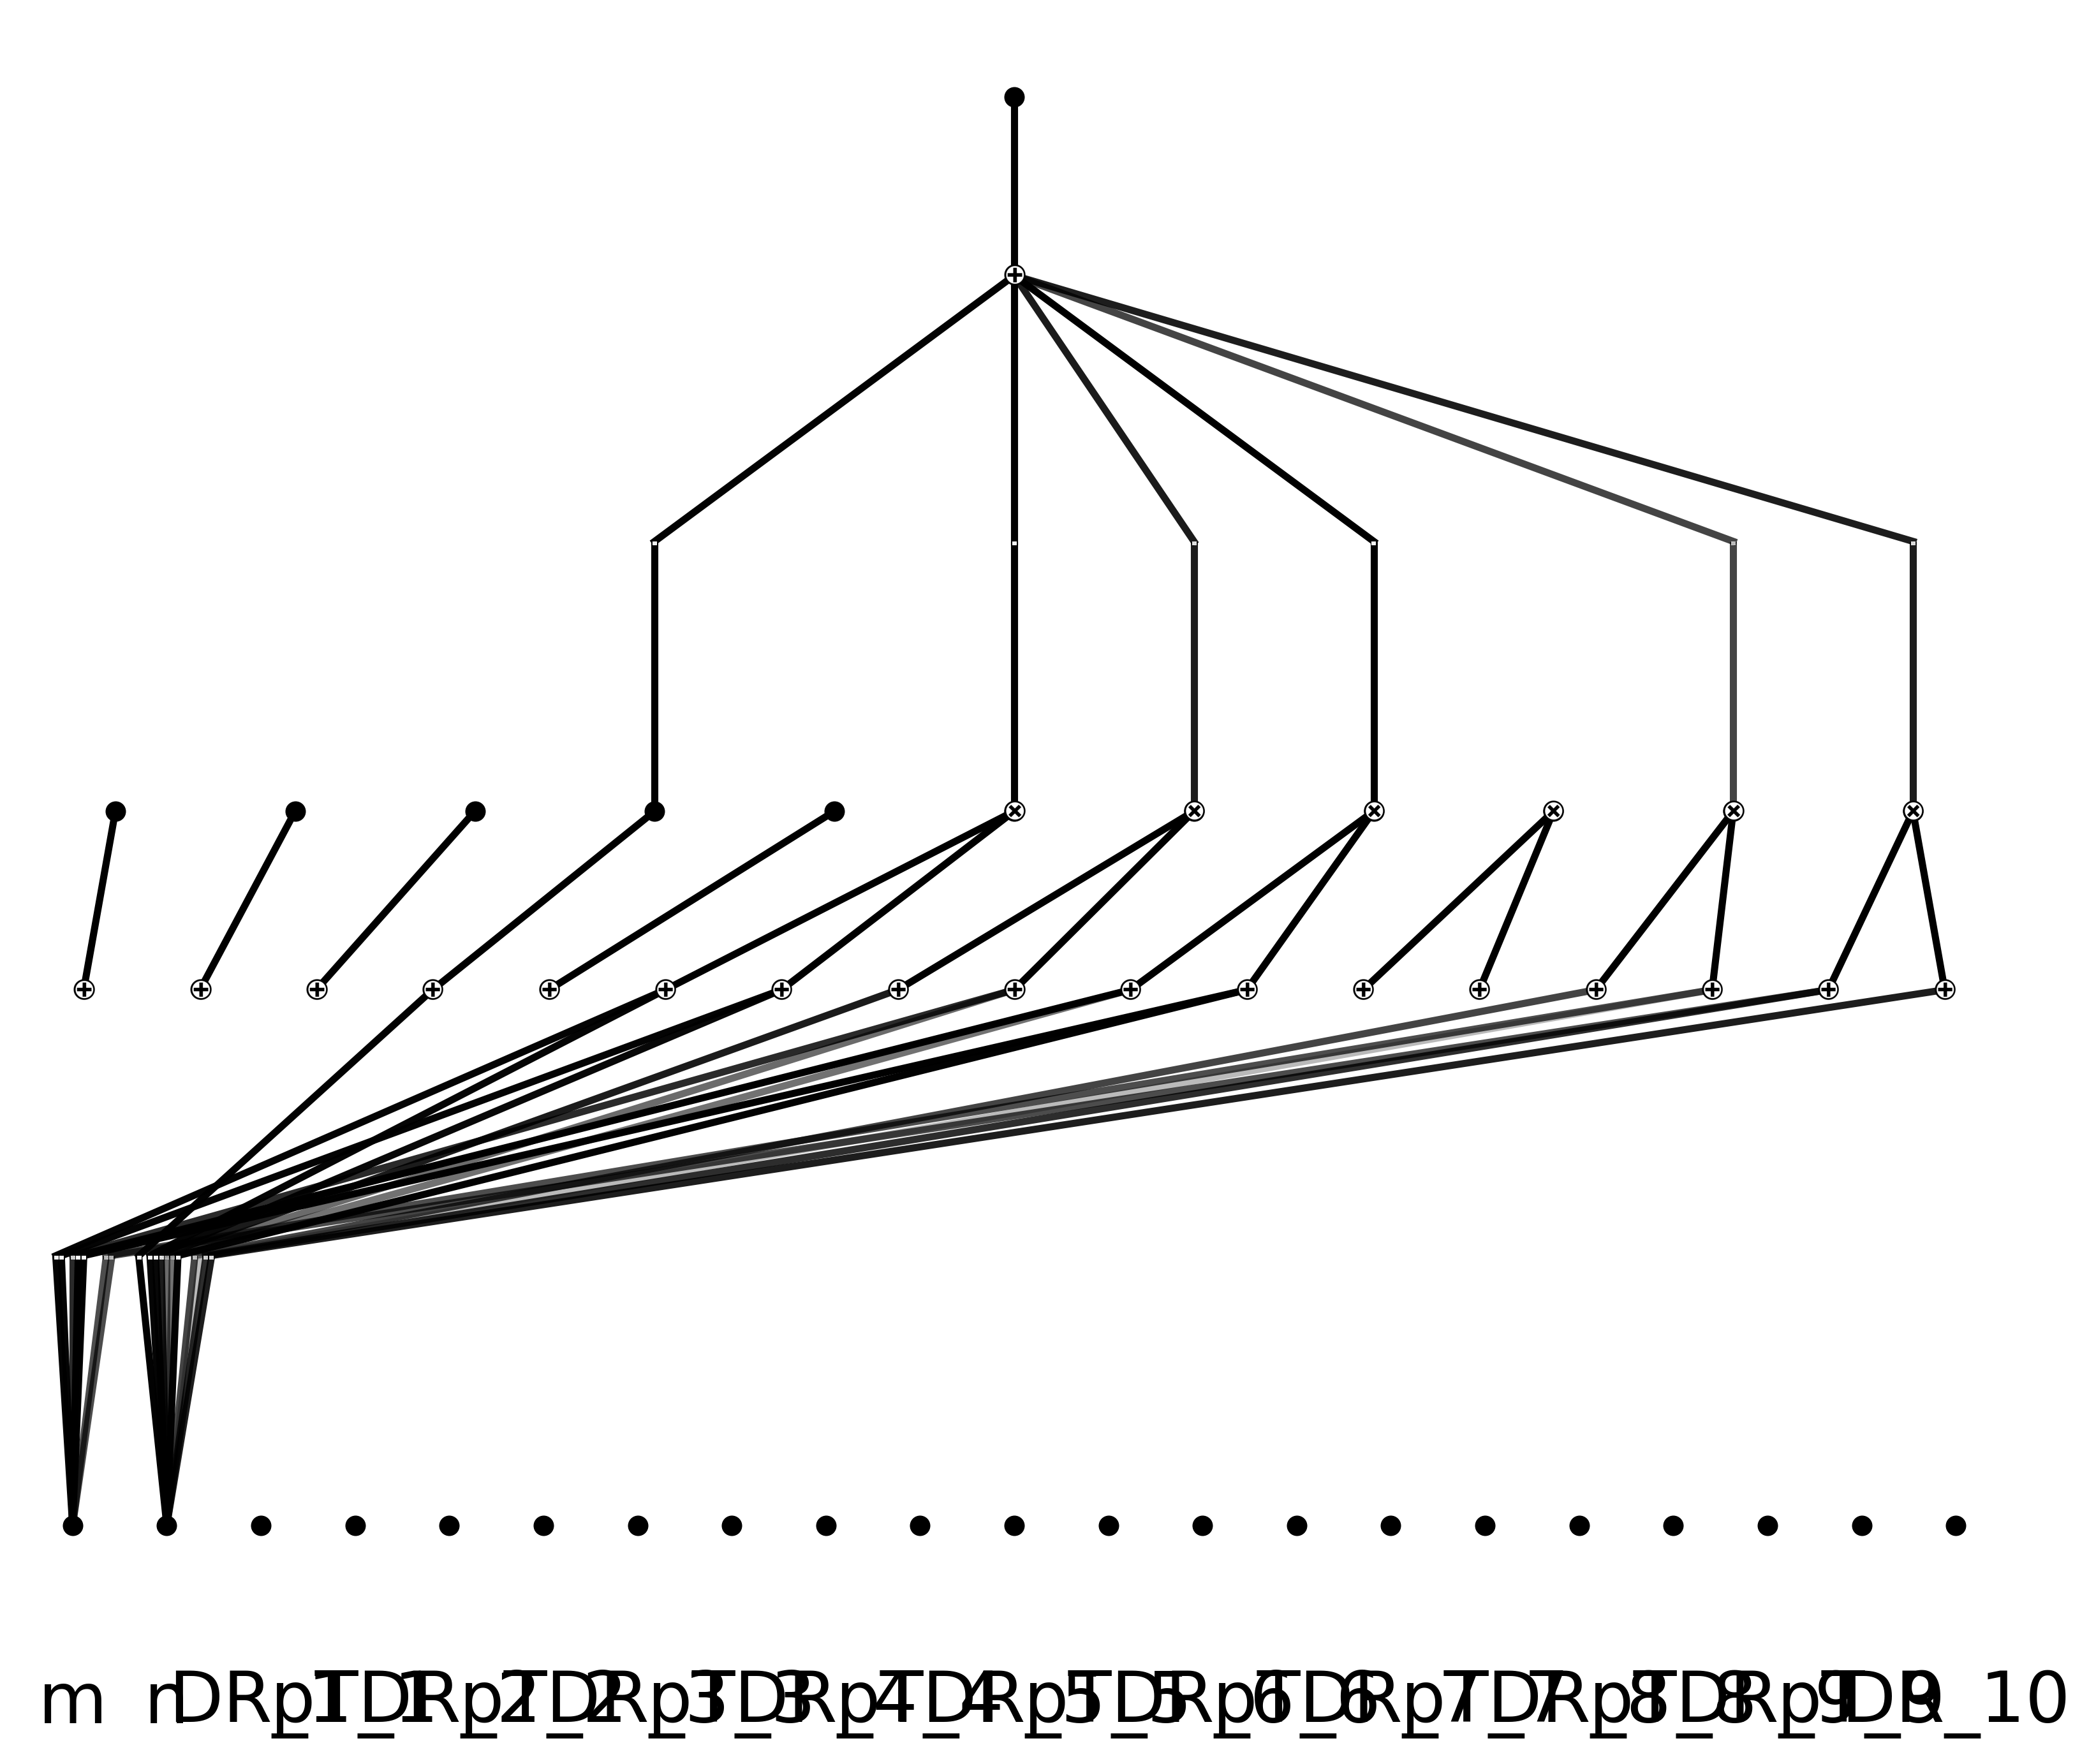

In [20]:
# show image
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/03_retrained/retrained_model.png")

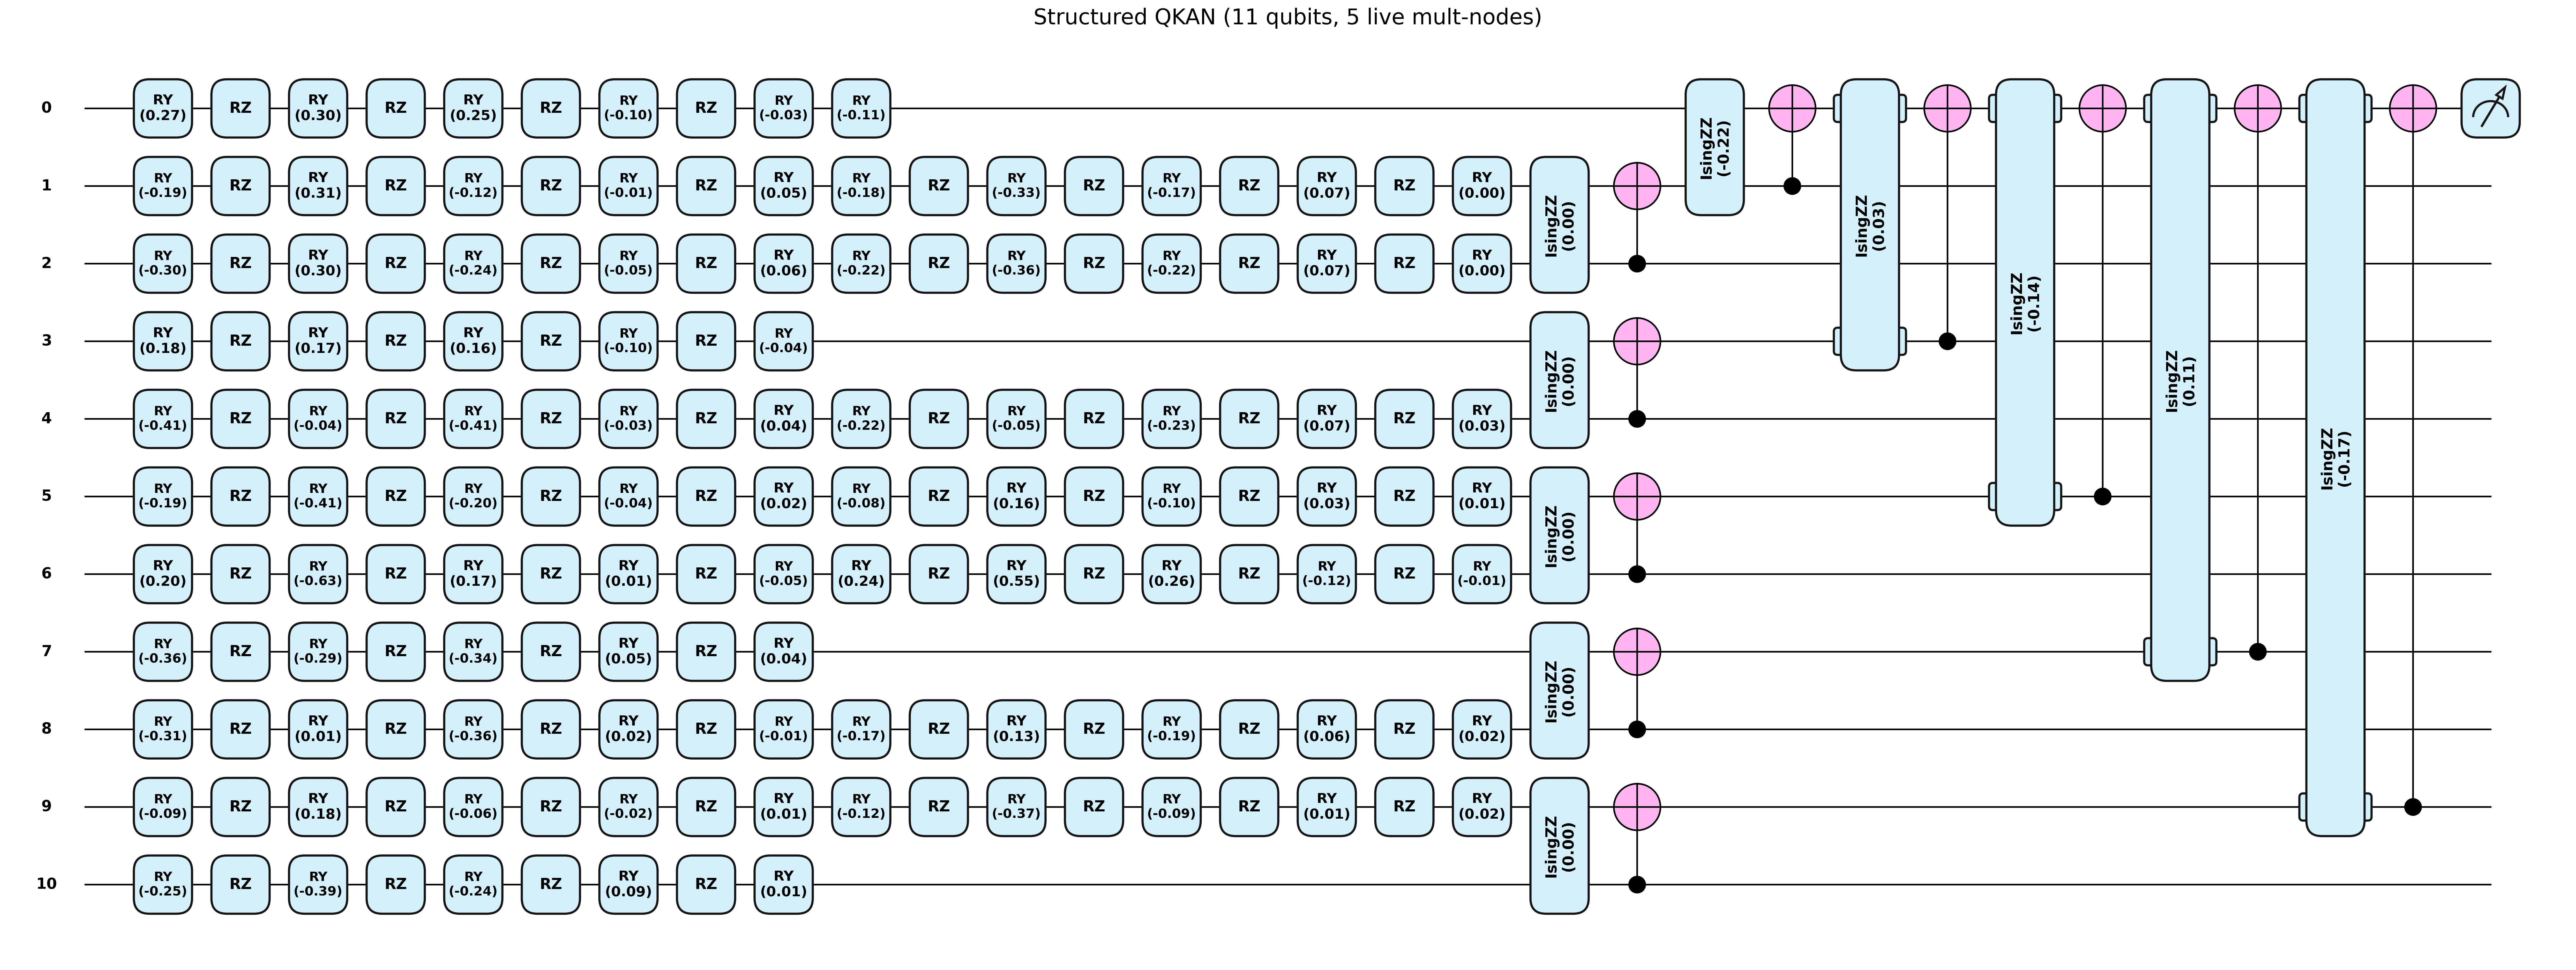

In [22]:
# show image
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/quantum-circuit.png")

Here the idea for the architecture is based on:
1) use Data Re-Uploading technique to model a function,
2) the hidden layer decides which features are important and the number of qubits,
3) the addition nodes are represented as consecutive DRU applications of the input features,
4) the multiplication nodes are represented with IsingZZ gate with a CNOT gate,
5) all the information is propagated through the network using these quantum operations and collapsed the information into one single wire with IsingZZ + CNOT gates.

### Quantum Implementation Details

The implementation consists of two core blocks:
1. **Model Definition (`src/architectures/qkan_model.py`)**: Defines the `QKANModel` PyTorch module, which builds the dynamic PennyLane circuit based on the extracted graph structure. It parses the active input-to-hidden edge map and configures either Chebyshev or Sine basis mapping, applying Data Re-Uploading (DRU). Multiplication nodes are mapped using global Entangling blocks (`IsingZZ` + `CNOT` gates).
2. **Hybrid Training Loop (`src/architectures/quantum_kan.py`)**: Defines the `QuantumKANTrainer` that implements mini-batch training using `Adam` optimizer, learning rate schedulers (`ReduceLROnPlateau`), and handles logging/checkpoints. It allows switching between various simulation backends: `"ideal"`, and `"noisy"`.

Let's read both of these source files to inspect their logic directly.

In [11]:
!cat ../src/architectures/qkan_model.py

# src/architectures/qkan_model.py
import pennylane as qml
import torch
import torch.nn as nn
import os
import matplotlib.pyplot as plt

from src.architectures.sine_basis import build_sine_grid


class QKANModel(nn.Module):
    """
    QKAN with:
      - n_qubits = number of ACCUMULATORS (raw neurons/groups of the hidden
        layer that survive pruning), NOT the number of active inputs. An
        input can be re-uploaded onto several different wires if it feeds
        several branches; a wire is never identified with "the input".
      - Fan-out solved by re-uploading: the same classical variable is
        re-uploaded (RY/RZ) on every accumulator-wire where it participates,
        always read from its own data column (in_col), never from an
        "owned" wire that doesn't exist.
      - Summation within a node solved FOR FREE: applying RZ(theta) repeatedly
        on the SAME wire accumulates the angles (rotations on the same axis
        compose additively) -> no 2-qubit gates

In [12]:
!cat ../src/architectures/quantum_kan.py

# src/architectures/quantum_kan.py
import os
import time
import json
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score
from pathlib import Path
import sys

sys.path.append(str(Path(__file__).parent.parent.resolve()))
from src.architectures.qkan_model import QKANModel

class QuantumKANTrainer:
    def __init__(self, config, train_backend="ideal", random_init=False, graph_filename="quantum_weights.pt"):
        self.config = config
        self.train_backend = train_backend
        self.random_init = random_init
        # Use all available CPU cores for the classical-side work (loss,
        # optimizer, grad clipping) instead of an artificial fixed cap.
        torch.set_num_threads(max(1, os.cpu_count() or 1))

        # Initialize the model pointing to the unified .pt file
        weights_path = os.path.join(self.config["polynomial_weights_dir"], graph_filename)
        self.model = QKANModel(graph_p

The quantum training process consists of two primary types of execution:

1. **Agnostic Baseline Comparative Evaluation**: Before any quantum parameter optimization happens, we can evaluate and compare the predictive signal that survives the classical-to-quantum extraction step. Using different mathematical bases (Chebyshev, Sine) or starting from a completely random initialization, we score the models on an ideal simulator. This is achieved via the script `scripts/eval_sine_baseline.py`.
2. **Quantum Fine-Tuning**: Once the classical KAN topology/coefficients have been extracted, we fine-tune the variational parameters on quantum simulator backends (`ideal` or `noisy`). This is executed using the `scripts/train_qkan.py` script.

Uncomment any of the following commands in the cell below to run these stages:

In [ ]:
# Evaluate baseline initializations (Chebyshev vs Sine vs Random VQC init) with NO training
#!python3 ../scripts/eval_sine_baseline.py --seeds 10 --task top

In [ ]:
# Run standard Chebyshev-basis warm-start QKAN model training (e.g. ideal backend)
#!python3 ../scripts/train_qkan.py --seed 10 --task top --train_backend ideal

In [ ]:
# Run random-VQC-initialized baseline model training (ablation study)
#!python3 ../scripts/train_qkan.py --seed 10 --task top --random_init

In [13]:
# View training log output
!cat ../outputs/top/mass_cut/n5_subset0/seed_10/logs/train_qkan_top_seed_10_ideal.log


[CACHE DETECTED] Loading canonical 5-way partition from: '/workspace/QKANs-ML4SCI_2026/data/processed/top/mass_cut/n5/preprocessed_subsets.pt'
>> Selecting subset 0 (seed=10 % n_subsets=5).
Setting global random seed 10 for reproducibility (run seed: subset selection).

[Extractor] Extracting structured graph (sum/mult) for QKAN
[Extractor] Evaluating active edges: inputs -> hidden layer...
[Extractor] 2 active classical variables (raw inputs: [0, 1])
[Extractor] Surviving hidden nodes: 1 sum, 5 mult
[Extractor] 11 qubits required (one per surviving accumulator/raw neuron, NOT one per input — may differ from the number of active classical variables)
[Extractor] Evaluating active edges: hidden layer -> output...
[Extractor] Active hidden->output edges: 6
[Extractor] Quantum graph exported to: /workspace/QKANs-ML4SCI_2026/outputs/top/mass_cut/n5_subset0/seed_10/models/quantum_weights/quantum_weights.pt
[QKAN] Plan built: 18 input edges, 5 IsingZZ transfers (multiplication), 6 output edg

### Fitting

#### Chebyshev fitting

To transfer the knowledge from the trained classical KAN model to the QKAN, we sequentially isolate the response of each active connection (edge). Using the class `src/architectures/extractor.py`, we evaluate the numerical response (B-spline) of each connection by disconnecting the rest of the inputs to the target node.

We then fit a Chebyshev polynomial to this isolated signal using the `chebfit` function:

$$y \approx \sum_{i=0}^N c_i T_i(x)$$

Where:
* $T_i(x)$ are the first-order Chebyshev polynomials defined recursively in $[-1, 1]$.
* $c_i$ are the fitted coefficients that will be exported to a serialized file `quantum_weights.pt`.

This extraction step provides a **"warm start"**, mapping these classical coefficients directly as initial weights in the angular rotation blocks of the quantum circuit in `src/architectures/qkan_model.py`. This ensures that the circuit has predictive signal and captures the classical topology before starting quantum training.

**Important Note:**

The chebyshev polynomials were fixed in a degree 4 for all edges. The initial dynamic search was focus in select the minimum degree that satisfied the R2 threshold, nevertheless it was later abandoned in favor of a fixed-degree approach because the model used to selected lower degree almost all the time and this led to inconsistent low-order metrics when evaluating the circuit loosing the information fo the classic KAN structure.

#### Sine fitting

As an alternative to the Chebyshev basis, we implemented a sinusoidal-based extractor called `src/architectures/extractor_sine.py`. This allows us to adjust the classical spline response using a multi-term sinusoidal basis, providing a different approach to initializing the QKAN model.

$$y \approx \sum_{k=1}^A A_k \sin(\text{freq}_k \cdot x + \text{phase}_k)$$

Where the frequencies $\text{freq}_k$ and phases $\text{phase}_k$ are determined by the sinusoidal grid in `src/architectures/sine_basis.py`, and the amplitudes $A_k$ are optimized via least squares fitting.

**Sinusoidal Extractor Analysis:**
Before training the quantum circuit, we evaluated the fit quality of the sinusoidal extractor:
* The sinusoidal basis with fixed frequencies and phases achieves a moderate fit ($\text{mean } R^2 \approx 0.49 - 0.61$), which is generally lower than the Chebyshev fit.
* The lack of a constant offset term in the fixed-frequency sines limits its ability to capture static shifts in the input range $[-1, 1]$, occasionally resulting in negative $R^2$ values for specific connections. To better results we need a deeper analysis or an extended basis that includes a constant term.

Despite these limitations, the sinusoidal extractor provides a reasonable starting point for the QKAN model compared to purely random initialization.

#### Random initialization

To calibrate the impact of the "warm start" (whether Chebyshev or Sine), we introduced a classical control scenario in quantum learning: **random initialization**.

In this approach, we keep the pruned topology of the classical model exactly the same (i.e., the number of active qubits and the connections between wires), but we initialize all rotational coefficients angularly with values sampled from a standard normal distribution:

$$\omega_i \sim \mathcal{N}(0, 1)$$

### Training VQC

The optimization process for the variational quantum classifier (VQC) is carried out through a hybrid classical-quantum training loop implemented in `src/architectures/quantum_kan.py`.

#### 1) Algorithm and Loss Functions
The circuit is trained with:
* **Cost function:** Binary cross-entropy with logits (`nn.BCEWithLogitsLoss`), measuring the distance between the observed expectation value in Pauli-Z and the true jet label (parton vs. gluon or top-quark vs. background).
* **Optimization:** `Adam` optimizer with a dynamic learning rate reduction schedule (`ReduceLROnPlateau`), halving the `learning_rate` if the validation loss does not improve for several consecutive epochs.

#### 2) Computational Challenge of the Simulator
Quantum simulation is computationally expensive ($O(2^Q)$ where $Q$ is the number of qubits). Therefore, to enable practical training, we implement an epoch-wise sub-sampling strategy:
* In each epoch, a fresh random subset of reduced size (e.g., $1000$ samples) is selected.
* Evaluation is performed on a fixed validation set to monitor overfitting and early stopping.

## Random forest

As a robust classical benchmark complementing the classical KAN and hybrid QKAN pipelines, we incorporate a non-linear ensemble model: the **Random Forest**, implemented in `src/architectures/random_forest.py` and executed via the `scripts/train_rf.py` script.

#### Features of the Classical Baseline:
* **Full input without constraints:** Unlike the quantum KAN network, which is forced into an extreme pruning process (commonly retaining only 2 variables such as the jet mass $m$ and multiplicity $n$ to keep the number of qubits manageable), the Random Forest is trained on the full matrix of **22 features** (including detailed substructure of the jet particles).
* **Robust Parameters:** We configure a forest of 500 trees (`rf_n_estimators=500`) with automatic class balancing (`rf_class_weight="balanced"`), which drastically reduces variance and provides highly stable probability estimates.

#### Feature Importance (Classical Interpretability):
The model calculates and reports the **Feature Importance (MDI/Gini)** metric (`rf_feature_importance.png`). This provides a very interesting interpretability counterbalance to the KAN activation functions:
1. Commonly, it reveals that the jet mass (`m_jet` or index 0) and the jet constituent multiplicity (`n_particles` or index 1) are, by a wide margin, the most predictive thermodynamic variables.
2. This mathematical finding retrospectively validates the extreme pruning of KAN: the KAN autonomously chooses to prune the rest of the inputs and retain only variables 0 and 1 to construct the quantum VQC, demonstrating that its regularization algorithm detects the same core information as the decision forest.

### Random Forest Implementation Details

The classical Random Forest baseline is encapsulated within the `RandomForestTrainer` class inside `src/architectures/random_forest.py`. 

- **Full-Feature Architecture**: Unlike KAN architectures, which aggressively prune features down to reduce qubit requirements (often down to only 2 features), the decision forest digests all **22 raw features** of the processed dataset.
- **Scikit-Learn Integration**: It configures and optimizes a standard `RandomForestClassifier` with balanced class weights, maximum depth, and a high number of decision estimators.
- **Metric Harmonization**: Its `evaluate_rf_model` method is specifically designed to calculate and return metrics in the exact same format and keys as the KAN trainer. This allows seamless aggregation via `src/utils/reporting.py` for comparative charts.

Let's read the Random Forest trainer source code:

In [14]:
!cat ../src/architectures/random_forest.py

# src/architectures/random_forest.py
import os
import sys
import numpy as np
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    f1_score, precision_score,
    recall_score, confusion_matrix, log_loss
)
import matplotlib.pyplot as plt

sys.path.append(str(Path(__file__).parent.parent.resolve()))
import src.utils.metrics as viz


class RandomForestTrainer:
    """
    Classical Random Forest baseline, trained/evaluated on the same
    processed-feature tensors and single-fold (--seed % n_subsets) selection
    the KAN pipeline uses (see ClassicKANTrainer in classic_kan.py). Unlike
    the KAN pipeline, this is a one-shot fit -- no epochs, no pruning/symbolic
    stages, no checkpoint history loop.
    """

    def __init__(self, config):
        """Initializes trainer with global CONFIG."""
        self.config = config
        self.model = None

    def train_rf_model(self, X_trai

In [ ]:
#!python3 ../scripts/train_rf.py --seed 10

In [15]:
!cat ../outputs/top/mass_cut/n5_subset0/seed_10/logs/rf_training_top_seed_10.log

Starting the Random Forest baseline pipeline. Task: top. Seed: 10.

--- Step 1: Loading and Preprocessing Data ---

[CACHE DETECTED] Loading canonical 5-way partition from: '/workspace/QKANs-ML4SCI_2026/data/processed/top/mass_cut/n5/preprocessed_subsets.pt'
>> Selecting subset 0 (seed=10 % n_subsets=5).
Setting global random seed 10 for reproducibility (run seed: subset selection).

--- Step 2: Training Random Forest ---
[RandomForestTrainer] Model saved to: /workspace/QKANs-ML4SCI_2026/outputs/top/mass_cut/n5_subset0/seed_10/models/rf/rf_model.joblib

--- Evaluation of Random Forest Model ---

--- Metrics on the Test Set (Random Forest) ---
Test Loss: 0.52277
Test Accuracy: 0.74636
Test F1 Score: 0.74585
Test AUC: 0.82207
Test Precision: 0.74735
Test Recall: 0.74435

Confusion Matrix:
[[3542 1191]
 [1210 3523]]
ROC curve plot saved to '/workspace/QKANs-ML4SCI_2026/outputs/top/mass_cut/n5_subset0/seed_10/plots/rf/rf_eval_roc.png'.
Precision-Recall curve plot saved to '/workspace/QKANs

### Summary

This workflow establishes a rigorous bridge between classical interpretability and noisy intermediate-scale quantum (NISQ) computing. By consolidating classical KAN, analytical feature extraction (Chebyshev / Sine), and variational quantum circuits (VQCs), we derive a fundamental design principle:
**Classical Pruning as a Qubit Filter:** Quantum networks are severely limited in physical size due to exponential simulation costs. Using Lasso/L1 regularizations and node penalties in classical KANs allows extracting the minimal core of input variables necessary.